# 2 — Model

Train Random Forest classifier (backend selection) and regressor (runtime estimation) from the final canonical training tables emitted by `0_preprocess.ipynb`. Compare with baselines. Generate figures for the paper.

**Run after** `0_preprocess.ipynb`.

In [97]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, mean_absolute_error, r2_score,
    root_mean_squared_error,
 )
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
C = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F",
     "#EDC948", "#B07AA1", "#FF9DA7", "#9C755F", "#BAB0AC"]

COL1_W = 3.5
COL2_W = 7.16

BASE = Path("/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related")
IMG = Path("images")
IMG.mkdir(parents=True, exist_ok=True)

best_df = pd.read_csv("final_data/use_this_for_classification.csv")
est_df  = pd.read_csv("final_data/use_this_for_regression.csv")
core_metrics = [
    c for c in [
        "depth", "width", "n_ops", "two_qubit_gates",
        "clifford_count", "nonclifford_count",
        "critical_path_length", "connected_components", "num_parameters",
    ] if c in est_df.columns
 ]
print(f"Classification data: {best_df.shape}")
print(f"Regression data:     {est_df.shape}")
print(f"Backend classes:     {sorted(best_df['best_backend'].dropna().unique())}")
print(f"Canonical metrics available: {core_metrics}")

Classification data: (218, 141)
Regression data:     (3500, 149)
Backend classes:     ['ibmq', 'ionq', 'nwqsim', 'qiskitaer', 'tnqvm']
Canonical metrics available: ['depth', 'width', 'n_ops', 'two_qubit_gates', 'clifford_count', 'nonclifford_count', 'critical_path_length', 'connected_components', 'num_parameters']


## 1. Backend Selection (Classification)

Predict the best backend (lowest runtime) from circuit features + resource config.

In [98]:
# Drop rows without labels or core feature(s).
clf_df = best_df.dropna(subset=["best_backend", "depth"]).copy()
print(f"Usable classification rows: {len(clf_df)}")

# Target
y_cls = clf_df["best_backend"]

# Features: drop identifiers, target, and label-leaking columns.
# `sub_backend` is the winning backend's sub-backend -> leakage; drop it.
# `n_qubits` duplicates `size`.
drop_cols = [
    "best_backend", "best_runtime", "benchmark", "sub_backend", "n_qubits",
    "backend", "arg_backend", "arg_sub_backend", "provider", "target_backend",
    "winning_backend", "oracle_backend",
]
X_cls = clf_df.drop(columns=[c for c in drop_cols if c in clf_df.columns])

# Remove infrastructure/provenance metadata that should not drive model choices.
infra_tokens = ["slurm", "timestamp", "filename", "job_id", "session", "account", "frontend_cluster"]
infra_cols = [c for c in X_cls.columns if any(tok in c.lower() for tok in infra_tokens)]
if infra_cols:
    print(f"Dropping infra/provenance columns: {sorted(infra_cols)}")
    X_cls = X_cls.drop(columns=infra_cols)

# Guardrail: if any suspicious backend-id columns still exist, remove them.
suspicious = [
    c for c in X_cls.columns
    if ("backend" in c.lower() or "provider" in c.lower()) and c not in {"backend_family"}
]
if suspicious:
    print(f"Dropping potential leakage columns: {suspicious}")
    X_cls = X_cls.drop(columns=suspicious)

# Pearson r > 0.95 correlation pruning on numeric features (per paper).
num_cols_all = X_cls.select_dtypes(exclude=["object"]).columns.tolist()
if len(num_cols_all) > 1:
    corr = X_cls[num_cols_all].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    redundant = [c for c in upper.columns if (upper[c] > 0.95).any()]
    if redundant:
        print(f"Dropping {len(redundant)} highly-correlated features (r>0.95)")
        X_cls = X_cls.drop(columns=redundant)

cat_cols = X_cls.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_cls.select_dtypes(exclude=["object"]).columns.tolist()

preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("numeric", SimpleImputer(strategy="median"), num_cols),
])

clf_pipe = Pipeline([
    ("pre", preprocessor),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=16,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )),
])

# Group-aware split to avoid train/test leakage from near-duplicate workloads.
group_keys = [c for c in ["benchmark", "size", "n_nodes", "n_processes", "run_mode", "device"] if c in clf_df.columns]
if group_keys:
    groups = clf_df[group_keys].astype(str).agg("|".join, axis=1)
else:
    groups = clf_df.index.astype(str)

n_groups = groups.nunique()
print(f"Unique workload groups for split: {n_groups}")

if n_groups >= 5:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    tr_idx, te_idx = next(gss.split(X_cls, y_cls, groups=groups))
    X_tr, X_te = X_cls.iloc[tr_idx], X_cls.iloc[te_idx]
    y_tr, y_te = y_cls.iloc[tr_idx], y_cls.iloc[te_idx]
    groups_tr = groups.iloc[tr_idx]
else:
    # Fallback for tiny datasets: random split with warning.
    print("[warn] Too few groups for GroupShuffleSplit; using row-wise split.")
    min_class = y_cls.value_counts().min()
    stratify = y_cls if min_class >= 2 else None
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_cls, y_cls, test_size=0.2, random_state=42, stratify=stratify
    )
    groups_tr = pd.Series(index=X_tr.index, data=X_tr.index.astype(str))

clf_pipe.fit(X_tr, y_tr)
y_hat = clf_pipe.predict(X_te)

acc = accuracy_score(y_te, y_hat)
f1 = f1_score(y_te, y_hat, average="macro", zero_division=0)
print(f"\n=== Classification Results (group-aware split) ===")
print(f"Accuracy:  {acc:.3f}")
print(f"Macro-F1:  {f1:.3f}")
print(f"\nClassification Report:")
print(classification_report(y_te, y_hat, zero_division=0))

# Group-aware CV on training partition for a less optimistic estimate.
if len(X_tr) >= 20 and groups_tr.nunique() >= 3:
    n_splits = min(5, groups_tr.nunique())
    if n_splits >= 2:
        gkf = GroupKFold(n_splits=n_splits)
        cv_scores = cross_val_score(
            clf_pipe, X_tr, y_tr,
            cv=gkf.split(X_tr, y_tr, groups=groups_tr),
            scoring="accuracy",
        )
        print(f"Group-CV Accuracy (train split): {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")

Usable classification rows: 95
Dropping potential leakage columns: ['be_backend_name', 'be_backend_type', 'be_backend_is_simulator']
Dropping 70 highly-correlated features (r>0.95)
Unique workload groups for split: 95


/tmp/ipykernel_3666489/4238126101.py:44: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_cls.select_dtypes(include=["object"]).columns.tolist()
/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'hw_gate_rx' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.


=== Classification Results (group-aware split) ===
Accuracy:  0.947
Macro-F1:  0.735

Classification Report:
              precision    recall  f1-score   support

        ibmq       1.00      1.00      1.00         9
        ionq       1.00      1.00      1.00         1
      nwqsim       0.89      1.00      0.94         8
   qiskitaer       0.00      0.00      0.00         1

    accuracy                           0.95        19
   macro avg       0.72      0.75      0.74        19
weighted avg       0.90      0.95      0.92        19



/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'hw_gate_rx' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'hw_gate_rx' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3.11/site-packages/sklearn/impute/_base.py:641: User

Group-CV Accuracy (train split): 0.948 +/- 0.050


/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'hw_gate_rx' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [99]:
# ── Baselines: Heuristic-based selection (Fig. 1) + always-NWQSim ──
#
# The static "heuristic" baseline is the simulator-selection decision
# tree shown in Fig. 1 (label `fig:sim_heuristics`, citing Alexeev 2024).
# Its branches are, in order:
#     1. <50 qubits      → state-vector family
#     2. depth <100      → tensor-network family
#     3. mostly Clifford → near-Clifford family
#     4. otherwise       → "candidate for quantum advantage" (abstain)
# It picks a *family*, not a concrete implementation, so we score it as
# correct when the true winning backend belongs to the predicted family.

SIM_LABELS    = {"qiskitaer", "nwqsim", "qtensor", "tnqvm"}
FAMILY_SV     = {"qiskitaer", "nwqsim"}      # state-vector
FAMILY_TN     = {"qtensor", "tnqvm"}         # tensor-network
FAMILY_CLIFF  = {"qiskitaer", "nwqsim"}      # stabilizer paths inside SV sims
ABSTAIN       = set()                        # "quantum advantage" branch

def heuristic_family(row):
    """Static simulator selector from Fig. 1. Returns a backend family
    (set of allowed labels) or empty set if the heuristic abstains."""
    nq    = row.get("size", row.get("n_qubits", 0)) or 0
    depth = row.get("depth", 0) or 0
    cliff    = row.get("clifford_count", row.get("num_cliffords", 0)) or 0
    noncliff = row.get("nonclifford_count", row.get("num_non_cliffords", 0)) or 0
    if pd.isna(nq): nq = 0
    if pd.isna(depth): depth = 0
    if pd.isna(cliff): cliff = 0
    if pd.isna(noncliff): noncliff = 0
    total_gates = cliff + noncliff
    cliff_frac = (cliff / total_gates) if total_gates > 0 else 0.0

    # Order matches the flowchart top→bottom.
    if nq < 50:
        return FAMILY_SV
    if depth < 100:
        return FAMILY_TN
    if cliff_frac >= 0.95:
        return FAMILY_CLIFF
    return ABSTAIN  # quantum-advantage regime: heuristic gives up

# Restrict heuristic evaluation to simulator-only test rows (fair).
sim_mask = y_te.isin(SIM_LABELS)
y_te_sim = y_te[sim_mask]
X_te_sim = X_te.loc[sim_mask]

if len(y_te_sim) > 0:
    heur_fam = X_te_sim.apply(heuristic_family, axis=1)
    bl_heur_sim = float(np.mean([truth in fam
                                 for truth, fam in zip(y_te_sim, heur_fam)]))
else:
    bl_heur_sim = float("nan")

# Full-test fairness: the heuristic abstains on hardware backends (no
# rule for IBMQ/IonQ) and on the "quantum advantage" branch. Abstain =
# wrong, so this is the metric directly comparable to MQBac's accuracy.
bl_heur = (bl_heur_sim * len(y_te_sim) / len(y_te)) if len(y_te) else float("nan")

# Need `present` and `most_common` below.
present = set(y_cls.unique())
most_common = y_cls.value_counts().idxmax()

# Always-NWQSim baseline (paper requirement) — full test set.
bl_nwqsim = accuracy_score(y_te, ["nwqsim"] * len(y_te)) if "nwqsim" in present else float("nan")

# Always-most-common baseline (sanity check).
bl_always = accuracy_score(y_te, [most_common] * len(y_te))

# ── Wall-clock speedup of MQBac-recommended vs Always-NWQSim ──
# Build an exact (benchmark, size, backend, n_nodes, n_processes) → mean_ms
# lookup from est_df. Fall back to (benchmark, size, backend) mean if missing.
_rt_cols = [c for c in ["benchmark", "size", "backend", "n_nodes", "n_processes"] if c in est_df.columns]
_target = "runtime_ms" if "runtime_ms" in est_df.columns else "mean_ms"
_rt_full = est_df.dropna(subset=[_target]).groupby(_rt_cols, dropna=False)[_target].mean()
_rt_bsb  = est_df.dropna(subset=[_target]).groupby(["benchmark", "size", "backend"], dropna=False)[_target].mean()

def _lookup_runtime(row, backend):
    key_full = tuple([row.get("benchmark"), row.get("size"), backend] +
                     [row.get(c) for c in ["n_nodes", "n_processes"] if c in _rt_cols])
    if key_full in _rt_full.index:
        return float(_rt_full.loc[key_full])
    key_bsb = (row.get("benchmark"), row.get("size"), backend)
    if key_bsb in _rt_bsb.index:
        return float(_rt_bsb.loc[key_bsb])
    return float("nan")

clf_te_idx = X_te.index
test_rows = clf_df.loc[clf_te_idx]
mqbac_pred = clf_pipe.predict(X_te)

rt_mqbac = np.array([_lookup_runtime(r, p) for (_, r), p in zip(test_rows.iterrows(), mqbac_pred)])
rt_nwq   = np.array([_lookup_runtime(r, "nwqsim") for _, r in test_rows.iterrows()])
rt_oracle = test_rows["best_runtime"].to_numpy(dtype=float)

valid = np.isfinite(rt_mqbac) & np.isfinite(rt_nwq) & (rt_mqbac > 0)
speedup_vs_nwqsim = float(np.nanmean(rt_nwq[valid] / rt_mqbac[valid])) if valid.any() else float("nan")
oracle_speedup    = float(np.nanmean(rt_nwq[valid] / np.maximum(rt_oracle[valid], 1e-9))) if valid.any() else float("nan")

print(f"\n=== Baseline Comparison ===")
print(f"MQBac RF accuracy:                 {acc:.3f}")
print(f"Heuristic (sim-only, family-aware): {bl_heur_sim:.3f}  (n={len(y_te_sim)})")
print(f"Heuristic (full test, abstain=wrong): {bl_heur:.3f}  ({len(y_te_sim)}/{len(y_te)} covered)")
print(f"Always-NWQSim accuracy:            {bl_nwqsim:.3f}")
print(f"Always-{most_common} (most common):   {bl_always:.3f}")
print(f"Mean MQBac speedup vs NWQSim:      {speedup_vs_nwqsim:.2f}x   (oracle: {oracle_speedup:.2f}x)")
print(f"  (lookup coverage: {valid.sum()}/{len(valid)} test rows)")



=== Baseline Comparison ===
MQBac RF accuracy:                 0.947
Heuristic (sim-only, family-aware): 1.000  (n=9)
Heuristic (full test, abstain=wrong): 0.474  (9/19 covered)
Always-NWQSim accuracy:            0.421
Always-nwqsim (most common):   0.421
Mean MQBac speedup vs NWQSim:      3.95x   (oracle: 4.12x)
  (lookup coverage: 12/19 test rows)


/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'hw_gate_rx' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


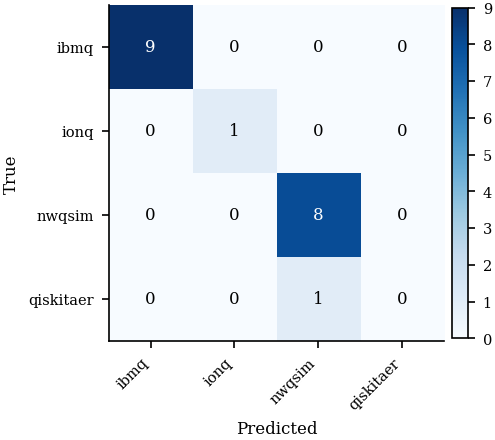

In [100]:
# Confusion matrix (single-column paper figure)
labels = sorted(y_cls.unique())
cm = confusion_matrix(y_te, y_hat, labels=labels)

fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.95))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
plt.tight_layout()
fig.savefig(IMG / "mqbac_confusion_matrix.pdf")
plt.show()


In [101]:
# === Classification Performance Table ===
from sklearn.metrics import classification_report
clf_report = classification_report(y_te, y_hat, output_dict=True, zero_division=0)
clf_df = pd.DataFrame(clf_report).transpose()
clf_df = clf_df[['precision', 'recall', 'f1-score', 'support']].round(3)
TABLES_DIR = Path("tables")
TABLES_DIR.mkdir(exist_ok=True)
with open(TABLES_DIR / "classification_performance.tex", "w") as f:
    f.write(clf_df.to_latex())
print("Saved: classification_performance.tex")
print(clf_df)

Saved: classification_performance.tex
              precision  recall  f1-score  support
ibmq              1.000   1.000     1.000    9.000
ionq              1.000   1.000     1.000    1.000
nwqsim            0.889   1.000     0.941    8.000
qiskitaer         0.000   0.000     0.000    1.000
accuracy          0.947   0.947     0.947    0.947
macro avg         0.722   0.750     0.735   19.000
weighted avg      0.901   0.947     0.923   19.000


In [102]:
# Per-class precision/recall plot removed (not used in paper; unstable signal across splits).
print("[skipped] mqbac_per_class_accuracy (removed as non-actionable)")

[skipped] mqbac_per_class_accuracy (removed as non-actionable)


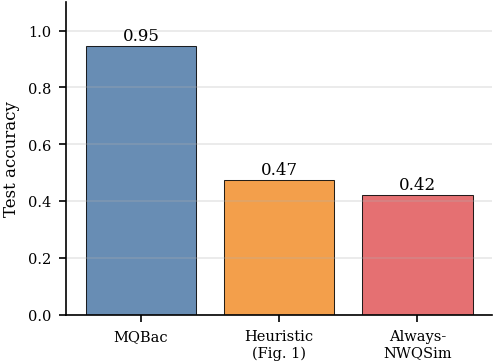

In [103]:
# Baseline comparison: MQBac vs Heuristic (Fig. 1, full-test, abstain=wrong)
# vs Always-NWQSim. `most_common` is dropped when it equals NWQSim to avoid
# duplicate bars.
methods = ["MQBac", "Heuristic\n(Fig.\u00a01)", "Always-\nNWQSim"]
accs    = [acc, bl_heur, bl_nwqsim]
bar_colors = [C[0], C[1], C[2]]
if most_common != "nwqsim":
    methods.append(f"Always-\n{most_common}")
    accs.append(bl_always)
    bar_colors.append(C[3])

fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.75))
bars = ax.bar(methods, accs, color=bar_colors, edgecolor="black",
              linewidth=0.5, alpha=0.85)
for bar, v in zip(bars, accs):
    if isinstance(v, float) and (v != v):
        continue
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + 0.02 if v > 0.02 else 0.04,
            f"{v:.2f}", ha="center")
ax.set_ylim(0, 1.1)
ax.set_ylabel("Test accuracy")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(IMG / "mqbac_baseline_comparison.pdf")
plt.show()


## 2. Runtime Estimation (Regression)

Predict `mean_ms` from circuit features + backend + resource config.

In [104]:
# Per the paper, the regressor predicts mean wall-clock time (`mean_ms`)
# per workload tuple. Aggregate per-sample timings to a per-tuple mean
# before training so target matches paper.
target_col = "runtime_ms" if "runtime_ms" in est_df.columns else "mean_ms"

reg_df = est_df.dropna(subset=[target_col]).copy()
reg_df = reg_df.dropna(subset=["depth"])

GROUP_KEYS = ["benchmark", "size", "backend", "sub_backend",
              "device", "run_mode", "n_nodes", "n_processes"]
group_keys = [c for c in GROUP_KEYS if c in reg_df.columns]

# Numeric features (mean) + categoricals (first) collapsed per group.
num_feat_cols = [c for c in reg_df.columns
                 if c not in group_keys + [target_col, "std_ms"]
                 and pd.api.types.is_numeric_dtype(reg_df[c])]
agg_dict = {target_col: "mean", **{c: "mean" for c in num_feat_cols}}
reg_mean_df = (
    reg_df.groupby(group_keys, dropna=False)
          .agg(agg_dict)
          .reset_index()
          .rename(columns={target_col: "mean_ms"})
)
print(f"Per-sample regression rows: {len(reg_df)}")
print(f"Aggregated to mean_ms per group: {len(reg_mean_df)}")

y_reg = reg_mean_df["mean_ms"].values

drop_cols = ["mean_ms", "std_ms", "n_qubits", "benchmark"]
X_reg = reg_mean_df.drop(columns=[c for c in drop_cols if c in reg_mean_df.columns])

# Remove infrastructure/provenance metadata that should not dominate feature ranks.
infra_tokens = ["slurm", "timestamp", "filename", "job_id", "session", "account", "frontend_cluster"]
infra_cols_reg = [c for c in X_reg.columns if any(tok in c.lower() for tok in infra_tokens)]
if infra_cols_reg:
    print(f"Dropping infra/provenance regression columns: {sorted(infra_cols_reg)}")
    X_reg = X_reg.drop(columns=infra_cols_reg)

# Pearson r > 0.95 correlation pruning on numeric features (per paper).
num_cols_all = X_reg.select_dtypes(exclude=["object"]).columns.tolist()
if len(num_cols_all) > 1:
    corr = X_reg[num_cols_all].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    redundant = [c for c in upper.columns if (upper[c] > 0.95).any()]
    if redundant:
        print(f"Dropping {len(redundant)} highly-correlated regression features (r>0.95)")
        X_reg = X_reg.drop(columns=redundant)

cat_cols_r = X_reg.select_dtypes(include=["object"]).columns.tolist()
num_cols_r = X_reg.select_dtypes(exclude=["object"]).columns.tolist()

pre_r = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols_r),
    ("numeric", SimpleImputer(strategy="median"), num_cols_r),
])

reg_pipe = Pipeline([
    ("pre", pre_r),
    ("rf", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)),
])

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_pipe.fit(Xr_tr, yr_tr)
yr_hat = reg_pipe.predict(Xr_te)

mae = mean_absolute_error(yr_te, yr_hat)
rmse = np.sqrt(((yr_te - yr_hat) ** 2).mean())
r2 = r2_score(yr_te, yr_hat)

print(f"\n=== Regression Results ===")
print(f"Target: mean_ms (per (benchmark,size,backend,...) tuple)")
print(f"MAE:   {mae:.2f} ms")
print(f"RMSE:  {rmse:.2f} ms")
print(f"R²:    {r2:.3f}")

Per-sample regression rows: 1879
Aggregated to mean_ms per group: 313
Dropping 82 highly-correlated regression features (r>0.95)


/tmp/ipykernel_3666489/680973327.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()
/tmp/ipykernel_3666489/680973327.py:49: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_r = X_reg.select_dtypes(include=["object"]).columns.tolist()
/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3


=== Regression Results ===
Target: mean_ms (per (benchmark,size,backend,...) tuple)
MAE:   3530.56 ms
RMSE:  8797.13 ms
R²:    0.953


/lustre/orion/gen008/proj-shared/qhpc/srikar/qfw_related/MQBac/mqbacVirtEnv/lib64/python3.11/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['num_control_flow_ops' 'dag_duration' 'qc_duration' 'hw_gate_gpi2'
 'hw_gate_ms' 'hw_gate_gpi' 'hw_gate_ry' 'algo_shots']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


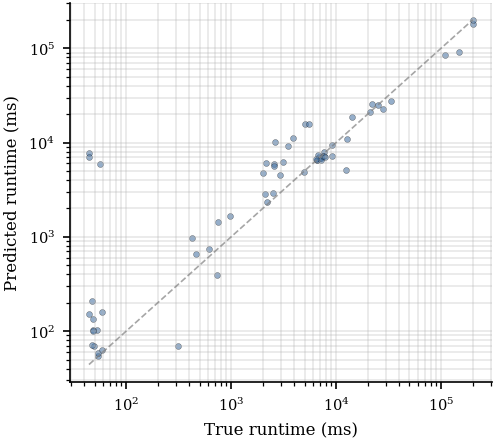

In [105]:
# Regression scatter (single-column paper figure, log-log handles huge dynamic range).
fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.9))
ax.scatter(yr_te, yr_hat, s=8, alpha=0.6, color=C[0],
           edgecolors="black", linewidths=0.2)
_lo = max(min(yr_te.min(), yr_hat.min()), 1e-3)
_hi = max(yr_te.max(), yr_hat.max())
ax.plot([_lo, _hi], [_lo, _hi], "--", color="gray", linewidth=0.8, alpha=0.7)
if _hi / max(_lo, 1e-9) > 1e2:
    ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("True runtime (ms)")
ax.set_ylabel("Predicted runtime (ms)")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
fig.savefig(IMG / "mqbac_regression_scatter.pdf")
plt.show()


In [106]:
# === Regression Performance Table ===
reg_metrics = pd.DataFrame({
    "Metric": ["MAE (ms)", "RMSE (ms)", "R²", "Test samples"],
    "Value": [f"{mae:.2f}", f"{rmse:.2f}", f"{r2:.3f}", len(yr_te)]
})
with open(TABLES_DIR / "regression_performance.tex", "w") as f:
    f.write(reg_metrics.to_latex(index=False))
print("Saved: regression_performance.tex")
print(reg_metrics)

Saved: regression_performance.tex
         Metric    Value
0      MAE (ms)  3530.56
1     RMSE (ms)  8797.13
2            R²    0.953
3  Test samples       63


## 3. Feature Importance

Top-15 Gini importance from both the classifier and regressor.

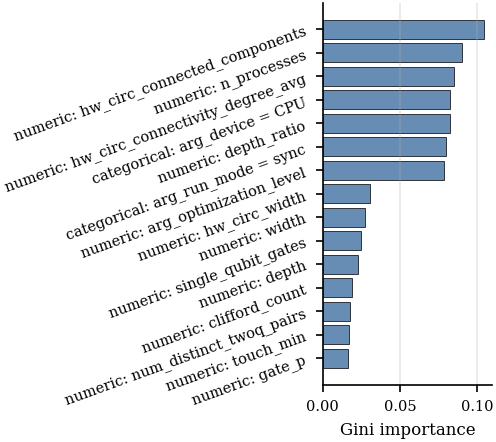

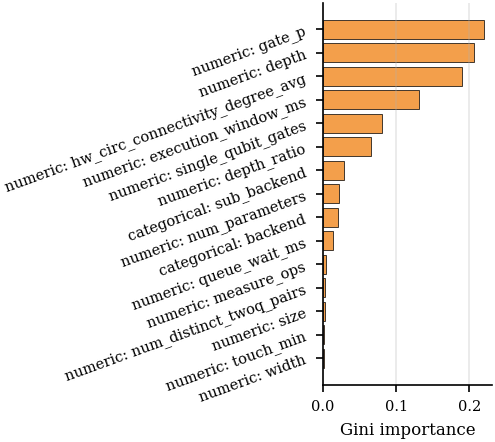

In [107]:
# Top-15 feature importance (separate paper figures: classifier and regressor).
def _split_categorical_raw(raw: str, feature_hints=None):
    hints = sorted(feature_hints or [], key=len, reverse=True)
    for feat in hints:
        if raw == feat:
            return feat, None
        prefix = feat + "_"
        if raw.startswith(prefix):
            return feat, raw[len(prefix):]
    # Fallback if no hint matches.
    parts = raw.split("_")
    if len(parts) >= 2:
        return "_".join(parts[:-1]), parts[-1]
    return raw, None

def pretty_feature_name(name: str, feature_hints=None) -> str:
    if name.startswith("categorical__"):
        raw = name[len("categorical__"):].strip()
        feat, category = _split_categorical_raw(raw, feature_hints)
        if category is None or category == "":
            return f"categorical: {feat}"
        return f"categorical: {feat} = {category}"
    if name.startswith("numeric__"):
        return f"numeric: {name[len('numeric__'):].strip()}"
    if name.startswith("cat__"):
        raw = name[len("cat__"):].strip()
        feat, category = _split_categorical_raw(raw, feature_hints)
        if category is None or category == "":
            return f"categorical: {feat}"
        return f"categorical: {feat} = {category}"
    if name.startswith("num__"):
        return f"numeric: {name[len('num__'):].strip()}"
    return name

def _is_nan_category(label: str) -> bool:
    return label.startswith("categorical:") and label.endswith(" = nan")

def _collapse_categorical_levels(labels, importances, collapse_features=None):
    agg = {}
    for label, importance in zip(labels, importances):
        if _is_nan_category(label):
            continue
        key = label
        if label.startswith("categorical: ") and " = " in label:
            feature = label[len("categorical: "):].split(" = ", 1)[0]
            if collapse_features is None or feature in collapse_features:
                key = f"categorical: {feature}"
        agg[key] = agg.get(key, 0.0) + float(importance)
    s = pd.Series(agg, dtype=float).sort_values(ascending=False)
    return s

# ── Classifier importance data ──
rf_clf = clf_pipe.named_steps["rf"]
pre_clf = clf_pipe.named_steps["pre"]
try:
    feat_names_clf_raw = pre_clf.get_feature_names_out()
except AttributeError:
    feat_names_clf_raw = [f"f{i}" for i in range(len(rf_clf.feature_importances_))]
imp_clf_raw = rf_clf.feature_importances_

pretty_clf = np.array([pretty_feature_name(n, cat_cols) for n in feat_names_clf_raw], dtype=object)
keep_clf = np.array([not _is_nan_category(n) for n in pretty_clf], dtype=bool)
pretty_clf = pretty_clf[keep_clf]
imp_clf = imp_clf_raw[keep_clf]
order_clf = np.argsort(imp_clf)[::-1]
feat_names_clf = pretty_clf[order_clf]
imp_clf = imp_clf[order_clf]
idx_clf = np.arange(len(imp_clf))

# ── Regressor importance data ──
rf_reg = reg_pipe.named_steps["rf"]
pre_reg = reg_pipe.named_steps["pre"]
try:
    feat_names_reg_raw = pre_reg.get_feature_names_out()
except AttributeError:
    feat_names_reg_raw = [f"f{i}" for i in range(len(rf_reg.feature_importances_))]
imp_reg_raw = rf_reg.feature_importances_

pretty_reg = np.array([pretty_feature_name(n, cat_cols_r) for n in feat_names_reg_raw], dtype=object)
collapsed_reg = _collapse_categorical_levels(
    pretty_reg,
    imp_reg_raw,
    collapse_features={"backend", "sub_backend"},
)
feat_names_reg = collapsed_reg.index.to_numpy()
imp_reg = collapsed_reg.values
idx_reg = np.arange(len(imp_reg))

# ── Plot 1: classifier ──
fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.90))
topn_clf = min(15, len(imp_clf))
ax.barh(range(topn_clf), imp_clf[:topn_clf][::-1], color=C[0], edgecolor="black",
        linewidth=0.4, alpha=0.85)
ax.set_yticks(range(topn_clf))
ax.set_yticklabels(feat_names_clf[:topn_clf][::-1])
ax.tick_params(axis="y", labelrotation=20)
ax.set_xlabel("Gini importance")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(IMG / "mqbac_feature_importance_classifier.pdf")
plt.show()

# ── Plot 2: regressor ──
fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.90))
topn_reg = min(15, len(imp_reg))
ax.barh(range(topn_reg), imp_reg[:topn_reg][::-1], color=C[1], edgecolor="black",
        linewidth=0.4, alpha=0.85)
ax.set_yticks(range(topn_reg))
ax.set_yticklabels(feat_names_reg[:topn_reg][::-1])
ax.tick_params(axis="y", labelrotation=20)
ax.set_xlabel("Gini importance")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
fig.savefig(IMG / "mqbac_feature_importance_regressor.pdf")
plt.show()

In [108]:
# === Feature Importance Top-10 Table ===
top_10_clf = pd.DataFrame({
    "Rank": range(1, 11),
    "Classifier": [pretty_feature_name(feat_names_clf[i]) for i in idx_clf[:10]],
    "Importance": imp_clf[idx_clf[:10]].round(4)
})
top_10_reg = pd.DataFrame({
    "Rank": range(1, 11),
    "Regressor": [pretty_feature_name(feat_names_reg[i]) for i in idx_reg[:10]],
    "Importance": imp_reg[idx_reg[:10]].round(4)
})
# Side-by-side table
top_10 = pd.concat([top_10_clf, top_10_reg], axis=1)
with open(TABLES_DIR / "feature_importance_top10.tex", "w") as f:
    f.write(top_10.to_latex(index=False))
print("Saved: feature_importance_top10.tex")
print(top_10)

Saved: feature_importance_top10.tex
   Rank                                Classifier  Importance  Rank  \
0     1     numeric: hw_circ_connected_components      0.1046     1   
1     2                      numeric: n_processes      0.0901     2   
2     3  numeric: hw_circ_connectivity_degree_avg      0.0854     3   
3     4             categorical: arg_device = CPU      0.0828     4   
4     5                      numeric: depth_ratio      0.0823     5   
5     6          categorical: arg_run_mode = sync      0.0801     6   
6     7           numeric: arg_optimization_level      0.0783     7   
7     8                    numeric: hw_circ_width      0.0308     8   
8     9                            numeric: width      0.0271     9   
9    10               numeric: single_qubit_gates      0.0246    10   

                                  Regressor  Importance  
0                           numeric: gate_p      0.2197  
1                            numeric: depth      0.2066  
2  numer

## 4. Hidden Performance Crossovers

The abstract claims meta-backend benchmarking *uncovers crossovers
opaque to traditional benchmarking*. This figure shows mean wall-clock
runtime vs qubit count, one curve per backend, faceted by benchmark.
Stars mark the winning backend at each qubit size — when stars switch
backends as qubits grow, that is a crossover.


ghz: plotted 3 best-star points (all 6 backends present)


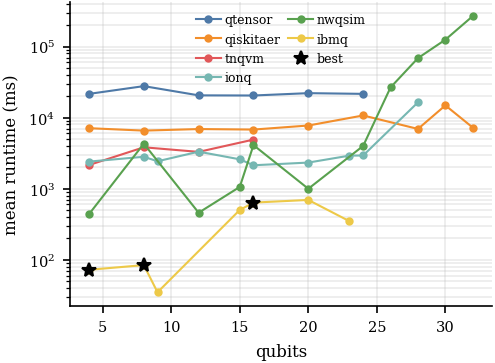

tfim: plotted 3 best-star points (all 6 backends present)


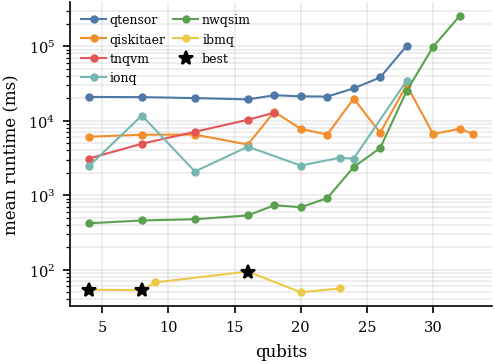

In [109]:
# Backend crossover figures (paper headline: "hidden crossovers").
# One single-column figure per benchmark; only GHZ and TFIM are kept.
_t = "runtime_ms" if "runtime_ms" in est_df.columns else "mean_ms"
_xover = (
    est_df.dropna(subset=[_t, "benchmark", "size", "backend"])
.         groupby(["benchmark", "size", "backend"], dropna=False)[_t]
.         mean()
.         reset_index()
)

# Keep only finite positive runtimes for log-scale plotting + star marking.
_xover = _xover[np.isfinite(_xover[_t]) & (_xover[_t] > 0)].copy()

_bench_map = {b.lower(): b for b in _xover["benchmark"].dropna().unique()}
_benches = [_bench_map[k] for k in ["ghz", "tfim"] if k in _bench_map]

# Legend order: qtensor, qiskitaer, tnqvm, ionq, nwqsim, ibmq, then best
legend_order = ["qtensor", "qiskitaer", "tnqvm", "ionq", "nwqsim", "ibmq"]
backend_color = {b: C[i % len(C)] for i, b in enumerate(legend_order)}

for bench in _benches:
    sub = _xover[_xover["benchmark"] == bench].copy()
    if sub["backend"].nunique() < 2:
        print(f"[skip] {bench}: only one backend; no crossover possible.")
        continue

    fig, ax = plt.subplots(figsize=(COL1_W, COL1_W * 0.75))

    # Comparable backends for this benchmark are those with any data and in legend order.
    comparable_backends = [b for b in legend_order if b in set(sub["backend"].unique())]

    # Plot in legend order
    for be in comparable_backends:
        g = sub[sub["backend"] == be]
        if len(g) > 0:
            g = g.sort_values("size")
            ax.plot(g["size"], g[_t], "-o",
                    color=backend_color[be], markersize=3,
                    linewidth=1.0, label=be)

    # Mark winners only where ALL comparable backend points are present at that size.
    _bcounts = sub.groupby("size")["backend"].nunique()
    _required = len(comparable_backends)
    _eligible_sizes = _bcounts[_bcounts == _required].index
    _sub_el = sub[sub["size"].isin(_eligible_sizes)]
    if not _sub_el.empty:
        winners = _sub_el.loc[_sub_el.groupby("size")[_t].idxmin()].sort_values("size")
        ax.plot(winners["size"], winners[_t], "*",
                color="black", markersize=7, zorder=6, label="best")
        print(f"{bench}: plotted {len(winners)} best-star points (all {_required} backends present)")
    else:
        print(f"{bench}: no sizes with all {_required} comparable backends; no stars plotted")

    ax.set_yscale("log")
    ax.set_xlabel("qubits")
    ax.set_ylabel("mean runtime (ms)")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(frameon=False, fontsize=6, ncol=2,
              handletextpad=0.3, columnspacing=0.6, loc="best")
    plt.tight_layout()
    out = IMG / f"mqbac_backend_crossovers_{bench.lower()}.pdf"
    fig.savefig(out)
    plt.show()


## 5. Summary for Paper

Numbers needed for Section 6 of `meta_backend_paper`.


In [110]:
print("=" * 60)
print("  NUMBERS FOR THE PAPER  (Section 6)")
print("=" * 60)

print(f"\n[Classification]")
print(f"  Accuracy:                            {acc:.3f}")
print(f"  Macro-F1:                            {f1:.3f}")
print(f"  Heuristic (Fig. 1, sim-only):        {bl_heur_sim:.3f}")
print(f"  Heuristic (Fig. 1, full test):       {bl_heur:.3f}")
print(f"  Always-NWQSim:                       {bl_nwqsim:.3f}")
print(f"  Always-{most_common} (most-common):     {bl_always:.3f}")
print(f"  Mean speedup vs Always-NWQSim:       {speedup_vs_nwqsim:.2f}x")

print(f"\n[Regression]  (target = mean_ms per workload tuple)")
print(f"  MAE:   {mae:.2f} ms")
print(f"  RMSE:  {rmse:.2f} ms")
print(f"  R²:    {r2:.3f}")

print(f"\n[Feature Importance — Classifier top 5]")
for rank, i in enumerate(idx_clf[:5], 1):
    print(f"  {rank}. {pretty_feature_name(feat_names_clf[i]):30s}  {imp_clf[i]:.4f}")

print(f"\n[Feature Importance — Regressor top 5]")
for rank, i in enumerate(idx_reg[:5], 1):
    print(f"  {rank}. {pretty_feature_name(feat_names_reg[i]):30s}  {imp_reg[i]:.4f}")


  NUMBERS FOR THE PAPER  (Section 6)

[Classification]
  Accuracy:                            0.947
  Macro-F1:                            0.735
  Heuristic (Fig. 1, sim-only):        1.000
  Heuristic (Fig. 1, full test):       0.474
  Always-NWQSim:                       0.421
  Always-nwqsim (most-common):     0.421
  Mean speedup vs Always-NWQSim:       3.95x

[Regression]  (target = mean_ms per workload tuple)
  MAE:   3530.56 ms
  RMSE:  8797.13 ms
  R²:    0.953

[Feature Importance — Classifier top 5]
  1. numeric: hw_circ_connected_components  0.1046
  2. numeric: n_processes            0.0901
  3. numeric: hw_circ_connectivity_degree_avg  0.0854
  4. categorical: arg_device = CPU   0.0828
  5. numeric: depth_ratio            0.0823

[Feature Importance — Regressor top 5]
  1. numeric: gate_p                 0.2197
  2. numeric: depth                  0.2066
  3. numeric: hw_circ_connectivity_degree_avg  0.1902
  4. numeric: execution_window_ms    0.1313
  5. numeric: single_q